N v/s n

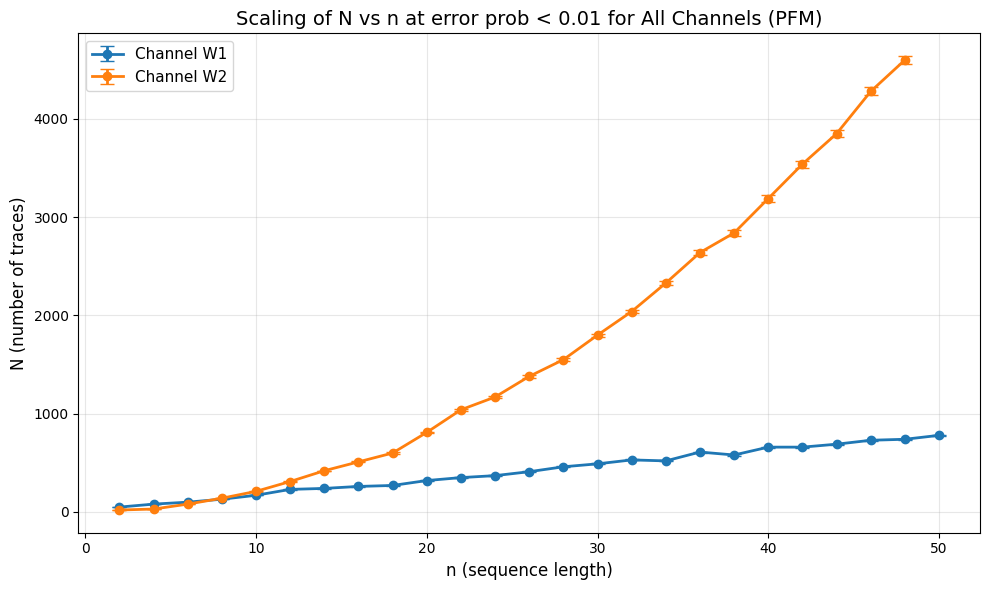

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV file
df = pd.read_csv('channel_results_pfm_large_range.csv')
# df = pd.read_csv('bitwise_large_range_with_ci_bounds.csv')


# Create plot
plt.figure(figsize=(10, 6))

# Plot each channel with error bars
for channel in df['Channel'].unique():
    channel_data = df[df['Channel'] == channel].sort_values('n')
    # Use Error column scaled by N as confidence interval
    plt.errorbar(channel_data['n'], channel_data['N'], 
                 yerr=channel_data['Error'] * channel_data['N'], 
                 marker='o', label=f'Channel {channel}', linewidth=2, capsize=5)

plt.xlabel('n (sequence length)', fontsize=12)
plt.ylabel('N (number of traces)', fontsize=12)
plt.title('Scaling of N vs n at error prob < 0.01 for All Channels (PFM)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

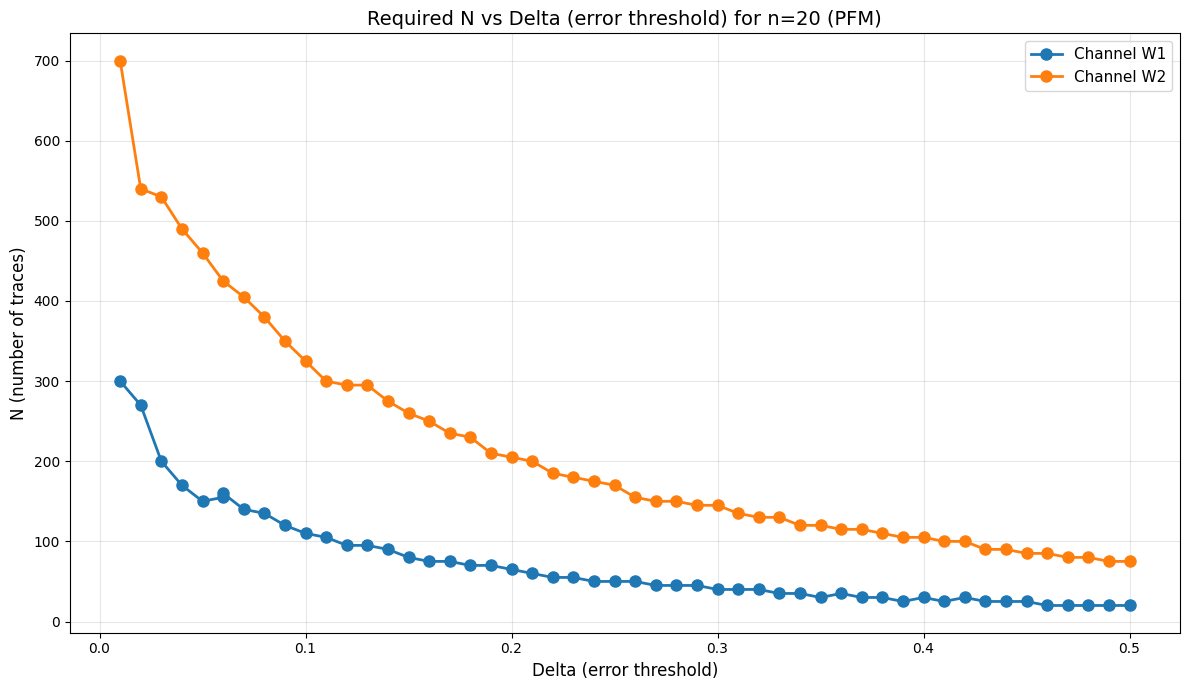

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV file
def plottesh(filename):
    df = pd.read_csv(filename)

    # Create plot
    plt.figure(figsize=(12, 7))

    # Plot each channel
    for channel in df['Channel'].unique():
        channel_data = df[df['Channel'] == channel].sort_values('Delta')
        plt.plot(channel_data['Delta'], channel_data['N'], marker='o', label=f'Channel {channel}', linewidth=2, markersize=8)

    plt.xlabel('Delta (error threshold)', fontsize=12)
    plt.ylabel('N (number of traces)', fontsize=12)
    plt.title('Required N vs Delta (error threshold) for n=20 (PFM)', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plottesh('channel_results_pfm_delta.csv')

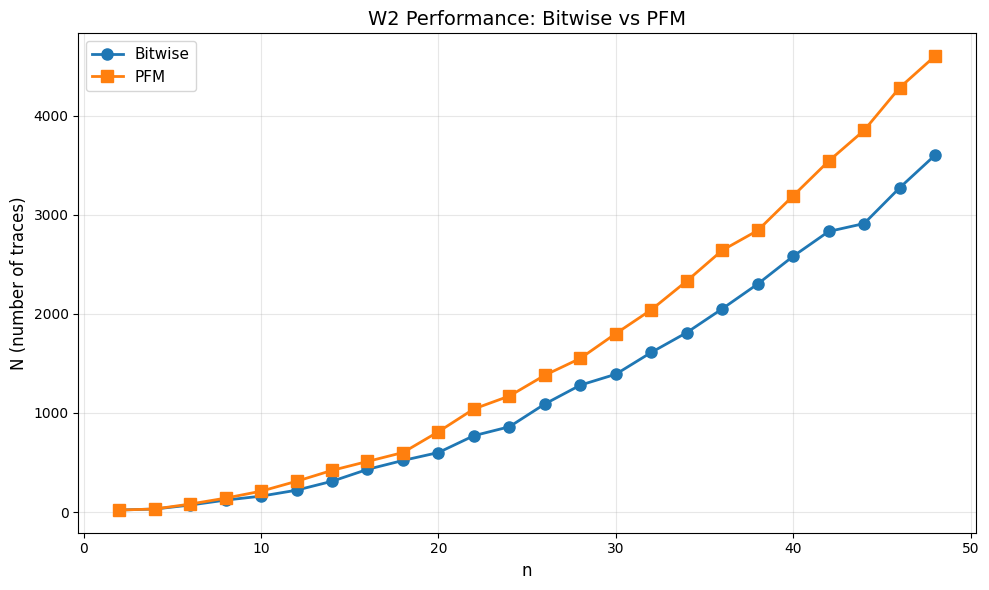

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV files for W1 bitwise and PFM
df_bitwise = pd.read_csv('channel_results_bitwise_large_range.csv')
df_pfm = pd.read_csv('channel_results_pfm_large_range.csv')

# Filter W2 data
df_bitwise_w2 = df_bitwise[df_bitwise['Channel'] == 'W2'].sort_values('n')
df_pfm_w2 = df_pfm[df_pfm['Channel'] == 'W2'].sort_values('n')

# Create plot
plt.figure(figsize=(10, 6))

plt.plot(df_bitwise_w2['n'], df_bitwise_w2['N'], marker='o', label='Bitwise', linewidth=2, markersize=8)
plt.plot(df_pfm_w2['n'], df_pfm_w2['N'], marker='s', label='PFM', linewidth=2, markersize=8)

plt.xlabel('n', fontsize=12)
plt.ylabel('N (number of traces)', fontsize=12)
plt.title('W2 Performance: Bitwise vs PFM', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

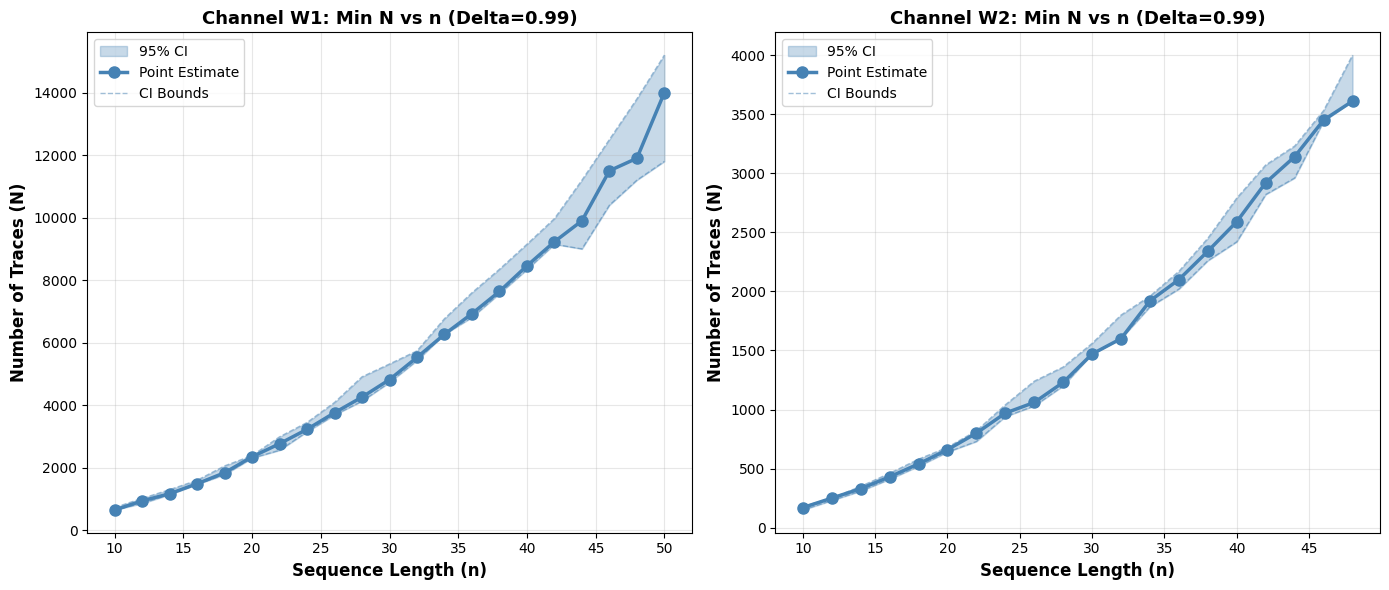

Plot saved to: N_vs_n_with_CI_shaded.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('bitwise_large_range_with_ci_bounds.csv')

# Create figure
fig, axes = plt.subplots(1, len(df['Channel'].unique()), figsize=(14, 6))
if len(df['Channel'].unique()) == 1:
    axes = [axes]

for idx, (ax, channel_name) in enumerate(zip(axes, df['Channel'].unique())):
    channel_data = df[df['Channel'] == channel_name].sort_values('n')
    
    n_vals = channel_data['n'].values
    N_central = channel_data['N_Central'].values
    N_lower = channel_data['N_Lower_CI'].values
    N_upper = channel_data['N_Upper_CI'].values
    
    # Shade the CI region
    ax.fill_between(n_vals, N_lower, N_upper, alpha=0.3, color='steelblue', label='95% CI')
    
    # Plot central line
    ax.plot(n_vals, N_central, 'o-', color='steelblue', linewidth=2.5, markersize=8, label='Point Estimate')
    
    # Plot bounds as dashed lines (optional, for clarity)
    ax.plot(n_vals, N_lower, '--', color='steelblue', alpha=0.5, linewidth=1, label='CI Bounds')
    ax.plot(n_vals, N_upper, '--', color='steelblue', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('Sequence Length (n)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Traces (N)', fontsize=12, fontweight='bold')
    ax.set_title(f'Channel {channel_name}: Min N vs n (Delta=0.99)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('N_vs_n_with_CI_shaded.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: N_vs_n_with_CI_shaded.png")

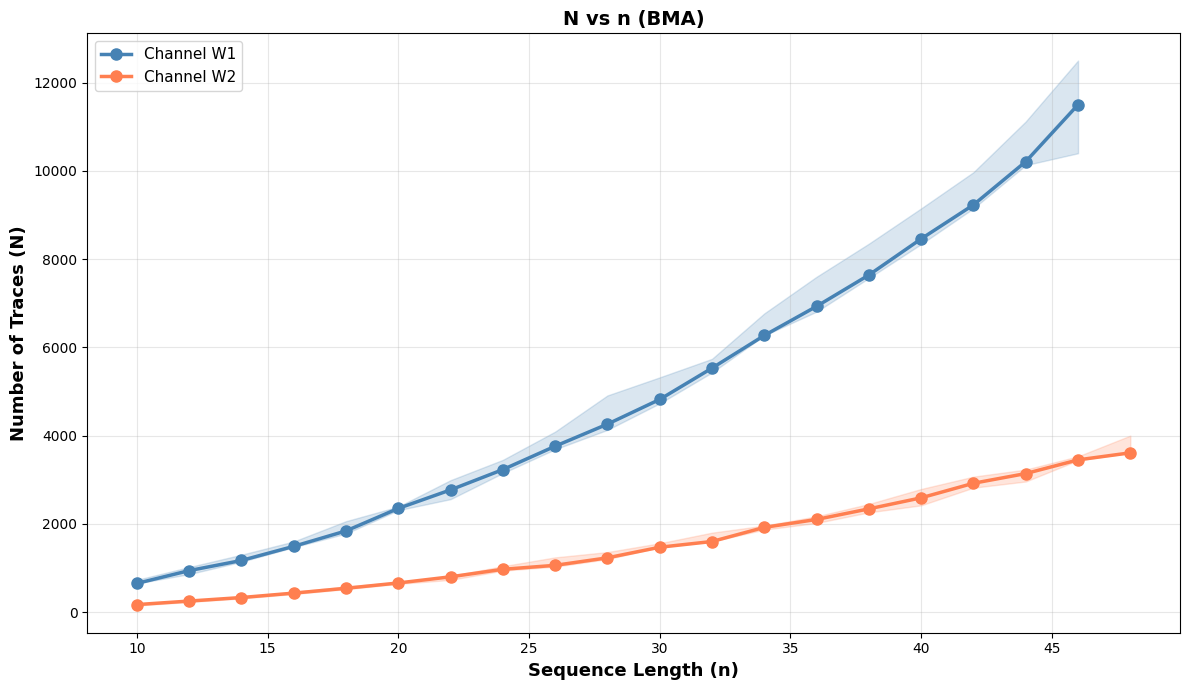

Plot saved to: N versus n w CI bma.png


In [38]:

# Plot all channels on same plot with CI shading
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('bitwise_large_range_with_ci_bounds.csv')
# df = pd.read_csv('bitwise_min_N_vs_delta_with_ci.csv')


# Create single figure
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors for each channel
colors = {'W1': 'steelblue', 'W2': 'coral', 'W3': 'forestgreen', 'W4': 'purple', 'W5': 'orange'}

for channel_name in sorted(df['Channel'].unique()):
    channel_data = df[df['Channel'] == channel_name].sort_values('n')
    
    n_vals = channel_data['n'].values
    N_central = channel_data['N_Central'].values
    N_lower = channel_data['N_Lower_CI'].values
    N_upper = channel_data['N_Upper_CI'].values
    
    color = colors.get(channel_name, 'gray')
    
    # Shade the CI region
    ax.fill_between(n_vals, N_lower, N_upper, alpha=0.2, color=color)
    
    # Plot central line
    ax.plot(n_vals, N_central, 'o-', color=color, linewidth=2.5, markersize=8, label=f'Channel {channel_name}')

ax.set_xlabel('Sequence Length (n)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Traces (N)', fontsize=13, fontweight='bold')
ax.set_title('N vs n (BMA)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('N versus n w CI bitwise.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: N versus n w CI bma.png")


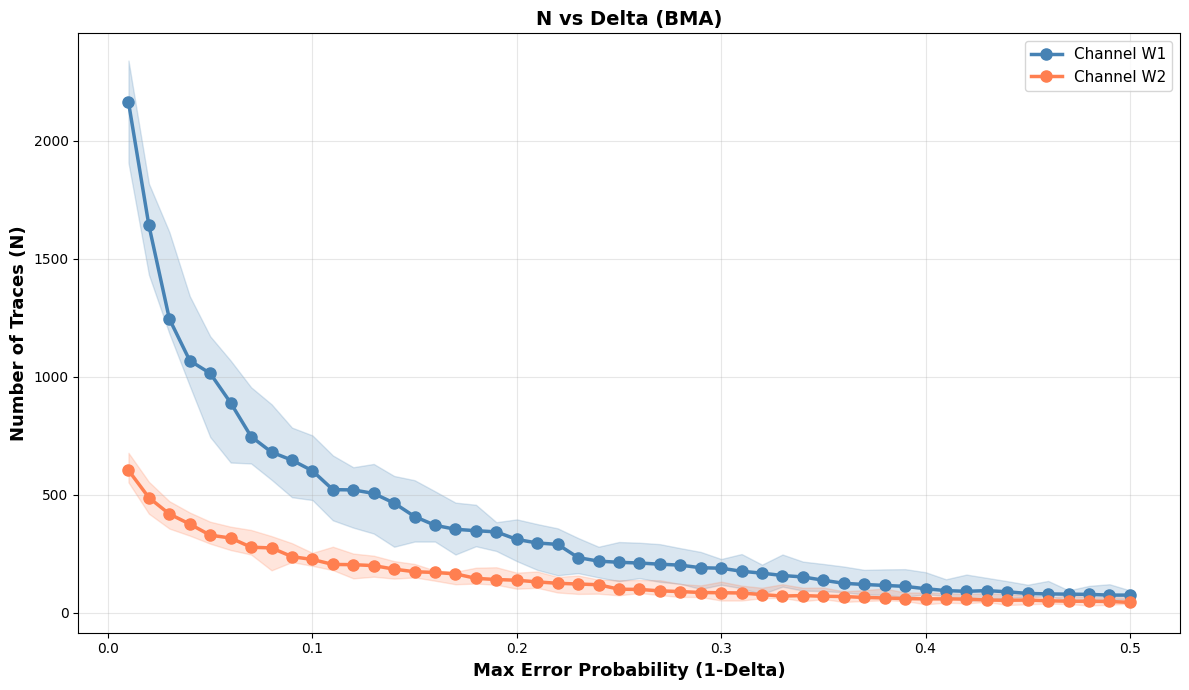

Plot saved to: N versus delta w CI Bitwise.png


In [39]:

# Plot all channels on same plot with CI shading
import pandas as pd
import matplotlib.pyplot as plt

# df = pd.read_csv('pfm_large_range_with_ci_bounds.csv')
df = pd.read_csv('bitwise_min_N_vs_delta_with_ci.csv')


# Create single figure
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors for each channel
colors = {'W1': 'steelblue', 'W2': 'coral'}

for channel_name in sorted(df['Channel'].unique()):
    channel_data = df[df['Channel'] == channel_name].sort_values('Delta_Target')
    
    delta_vals = channel_data['Delta_Target'].values
    N_central = channel_data['N_Central'].values
    N_lower = channel_data['N_Lower_CI'].values
    N_upper = channel_data['N_Upper_CI'].values
    
    color = colors.get(channel_name, 'gray')
    
    # Shade the CI region
    ax.fill_between(delta_vals, N_lower, N_upper, alpha=0.2, color=color)
    
    # Plot central line
    ax.plot(delta_vals, N_central, 'o-', color=color, linewidth=2.5, markersize=8, label=f'Channel {channel_name}')

ax.set_xlabel('Max Error Probability (1-Delta)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Traces (N)', fontsize=13, fontweight='bold')
ax.set_title('N vs Delta (BMA)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('N versus delta w CI Bitwise', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: N versus delta w CI Bitwise.png")


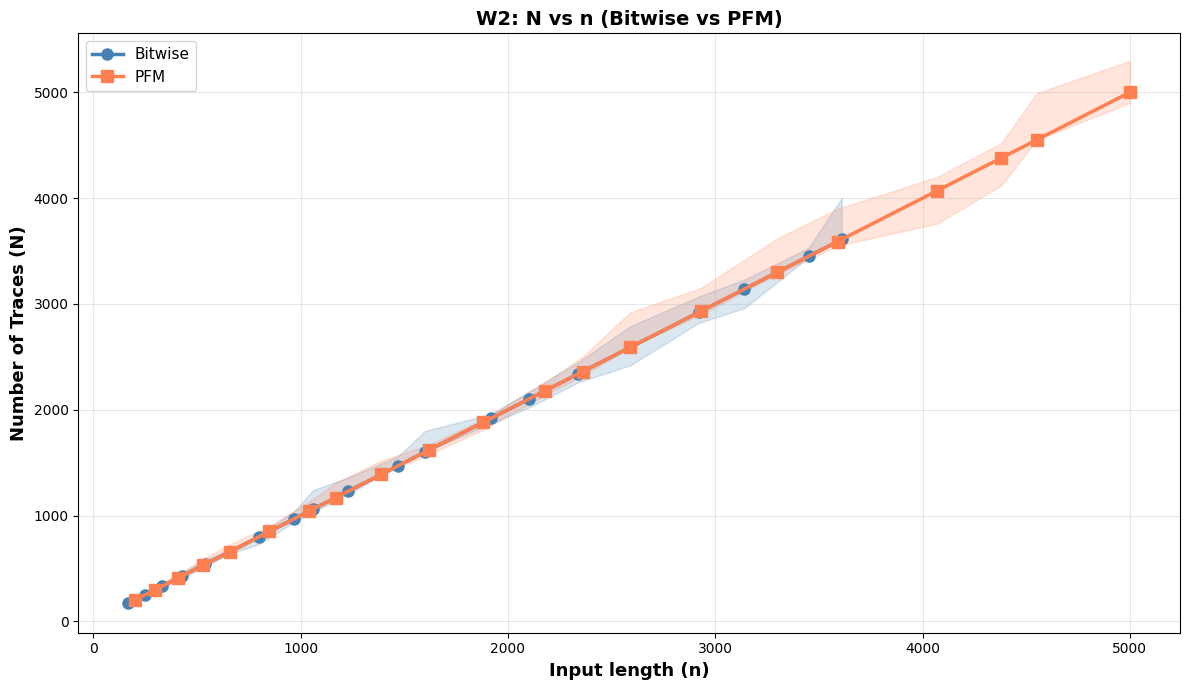

Plot saved to: W2_N_vs_Delta_Bitwise_vs_PFM.png


In [ ]:

# Plot W1 for both Bitwise and PFM algorithms on same plot
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV files for both algorithms
df_bitwise = pd.read_csv('bitwise_min_N_vs_delta_with_ci.csv')
df_pfm = pd.read_csv('pfm_min_N_vs_delta_with_ci.csv')

# Filter for W2 channel
df_bitwise_w2 = df_bitwise[df_bitwise['Channel'] == 'W2'].sort_values('Delta_Target')
df_pfm_w2 = df_pfm[df_pfm['Channel'] == 'W2'].sort_values('Delta_Target')

# Create single figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot Bitwise W2
delta_vals_bw = df_bitwise_w2['Delta_Target'].values
N_central_bw = df_bitwise_w2['N_Central'].values
N_lower_bw = df_bitwise_w2['N_Lower_CI'].values
N_upper_bw = df_bitwise_w2['N_Upper_CI'].values

ax.fill_between(delta_vals_bw, N_lower_bw, N_upper_bw, alpha=0.2, color='steelblue')
ax.plot(delta_vals_bw, N_central_bw, 'o-', color='steelblue', linewidth=2.5, markersize=8, label='Bitwise')

# Plot PFM W2
delta_vals_pfm = df_pfm_w2['Delta_Target'].values
N_central_pfm = df_pfm_w2['N_Central'].values
N_lower_pfm = df_pfm_w2['N_Lower_CI'].values
N_upper_pfm = df_pfm_w2['N_Upper_CI'].values

ax.fill_between(delta_vals_pfm, N_lower_pfm, N_upper_pfm, alpha=0.2, color='coral')
ax.plot(delta_vals_pfm, N_central_pfm, 's-', color='coral', linewidth=2.5, markersize=8, label='PFM')

ax.set_xlabel('Max Error Probability (1-Delta)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Traces (N)', fontsize=13, fontweight='bold')
ax.set_title('W2: N vs Delta (Bitwise vs PFM)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('W2 N versus delta.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: W1_N_vs_Delta_Bitwise_vs_PFM.png")


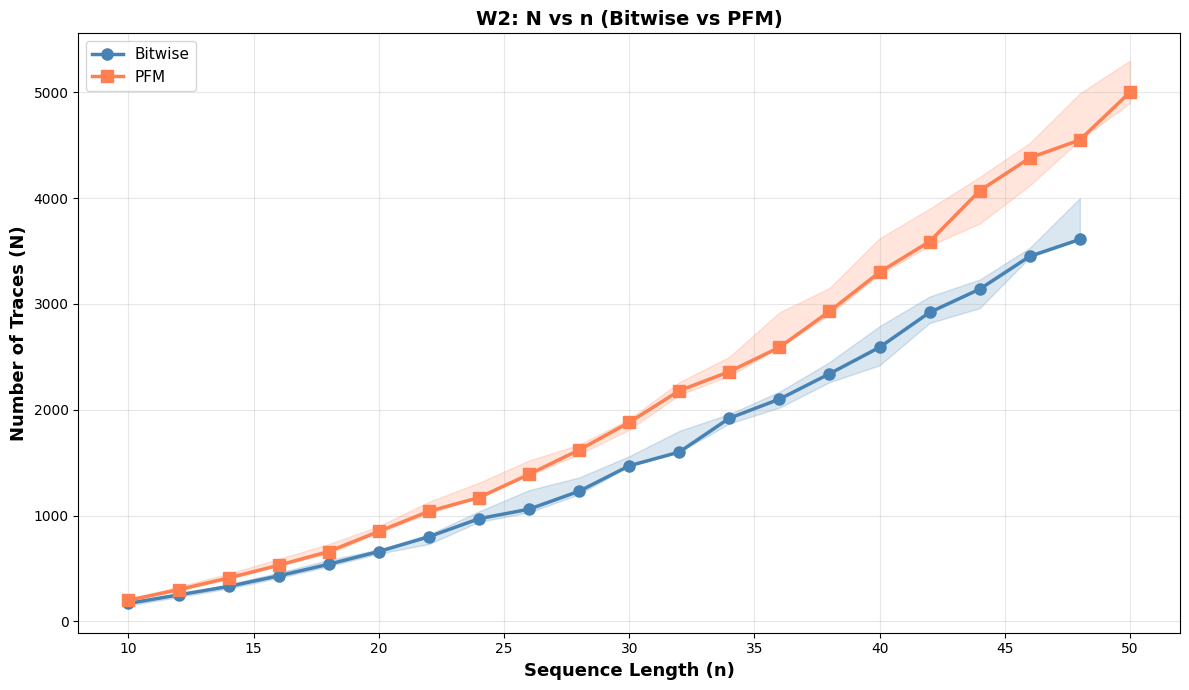

Plot saved to: W1_N_vs_n_Bitwise_vs_PFM.png


In [27]:

# Plot W1 N vs n for both Bitwise and PFM algorithms on same plot
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV files for both algorithms
df_bitwise = pd.read_csv('bitwise_large_range_with_ci_bounds.csv')
df_pfm = pd.read_csv('pfm_large_range_with_ci_bounds.csv')

# Filter for W2 channel
df_bitwise_w2 = df_bitwise[df_bitwise['Channel'] == 'W2'].sort_values('n')
df_pfm_w2 = df_pfm[df_pfm['Channel'] == 'W2'].sort_values('n')

# Create single figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plot Bitwise W2
n_vals_bw = df_bitwise_w2['n'].values
N_central_bw = df_bitwise_w2['N_Central'].values
N_lower_bw = df_bitwise_w2['N_Lower_CI'].values
N_upper_bw = df_bitwise_w2['N_Upper_CI'].values

ax.fill_between(n_vals_bw, N_lower_bw, N_upper_bw, alpha=0.2, color='steelblue')
ax.plot(n_vals_bw, N_central_bw, 'o-', color='steelblue', linewidth=2.5, markersize=8, label='Bitwise')

# Plot PFM W2
n_vals_pfm = df_pfm_w2['n'].values
N_central_pfm = df_pfm_w2['N_Central'].values
N_lower_pfm = df_pfm_w2['N_Lower_CI'].values
N_upper_pfm = df_pfm_w2['N_Upper_CI'].values

ax.fill_between(n_vals_pfm, N_lower_pfm, N_upper_pfm, alpha=0.2, color='coral')
ax.plot(n_vals_pfm, N_central_pfm, 's-', color='coral', linewidth=2.5, markersize=8, label='PFM')

ax.set_xlabel('Sequence Length (n)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Traces (N)', fontsize=13, fontweight='bold')
ax.set_title('W2: N vs n (Bitwise vs PFM)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('W2 N versus n.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: W1_N_vs_n_Bitwise_vs_PFM.png")
